# 04 · Combinational & Sequential Circuits
**Course:** SLAO · Chapter 3 *Les circuits logiques* + TD2 · ISG Tunis
**Covers:** half / full / *n*-bit adder, decoder, comparator, clock, SR latch, D / T / JK flip-flops, counter; TD2 exercises 2 (part 4), 3, 4

---

## Objectives
1. Build arithmetic and selection circuits **from gates only**, then prove them correct by exhaustive simulation.
2. Understand why a *combinational* circuit has no memory, and how feedback creates a *sequential* one.
3. Simulate an SR latch, characterise D / T / JK flip-flops, and assemble them into a **binary counter** with a timing diagram.

| | Combinational | Sequential |
|---|---|---|
| Output depends on | present inputs only | present inputs **and** stored state |
| Equation | $S = f(E)$ | $S_t = f(E,\;S_{t-1})$ |
| Building blocks | gates | gates + feedback (flip-flops) |
| Examples here | adders, decoder, comparator | latch, flip-flops, counter |

## Contents
1. Setup
2. Half adder and full adder
3. *n*-bit ripple-carry adder (exhaustive proof on 512 cases)
4. Decoder *n* → 2ⁿ (+ TD2 Ex. 2.4 and Ex. 4)
5. Comparator (TD2 Ex. 3)
6. Clock and timing
7. SR latch from two NOR gates
8. D, T and JK flip-flops
9. Application: a 3-bit synchronous counter

## 1 · Setup

In [1]:
%matplotlib inline
from __future__ import annotations
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import schemdraw
from schemdraw.parsing import logicparse

schemdraw.use("matplotlib")
pd.set_option("display.width", 120)

# --- gates (same definitions as notebook 03) ---------------------------------------------
def AND(*x):  return int(all(x))
def OR(*x):   return int(any(x))
def NOT(a):   return 1 - a
def NOR(*x):  return NOT(OR(*x))
def XOR(*x):  return sum(x) % 2
def XNOR(*x): return NOT(XOR(*x))


def draw_circuit(expr: str, label: str = "F") -> None:
    fig = logicparse(expr, outlabel=f"${label}$").draw(show=False).fig
    display(fig)
    plt.close(fig)


def table(rows, columns) -> pd.DataFrame:
    return pd.DataFrame(rows, columns=columns)

## 2 · Half adder and full adder

**Half adder (demi-additionneur)** – adds two 1-bit numbers $A, B$ and produces the sum $S$ and the carry $R$:

$$S = A \oplus B \qquad R = A \cdot B$$

**Full adder (additionneur complet)** – also takes the **incoming carry** $R_{i-1}$ coming from the lower-order column:

$$S_i = A_i \oplus B_i \oplus R_{i-1} \qquad R_i = A_i B_i + R_{i-1}(A_i \oplus B_i)$$

A full adder is two half adders plus an OR gate on the two carries – the structure implemented below.

In [2]:
def half_adder(a: int, b: int) -> tuple[int, int]:
    return XOR(a, b), AND(a, b)                       # (S, R)


def full_adder(a: int, b: int, r_in: int) -> tuple[int, int]:
    s1, c1 = half_adder(a, b)                         # first half adder: a + b
    s, c2 = half_adder(s1, r_in)                      # second half adder: + incoming carry
    return s, OR(c1, c2)                              # (S_i, R_i)


ha = table([(a, b, *half_adder(a, b)[::-1]) for a, b in itertools.product((0, 1), repeat=2)], ["A", "B", "R", "S"])
display(ha)
assert [ (r.A + r.B) for r in ha.itertuples()] == [2 * r.R + r.S for r in ha.itertuples()]   # arithmetic meaning

,A,B,R,S
0,0,0,0,0
1,0,1,0,1
2,1,0,0,1
3,1,1,1,0


In [3]:
rows = [(a, b, r, *full_adder(a, b, r)[::-1]) for a, b, r in itertools.product((0, 1), repeat=3)]
fa = table(rows, ["a_i", "b_i", "r_(i-1)", "r_i", "s_i"])
display(fa)

# Proof against the closed-form equations of the course
for a, b, r in itertools.product((0, 1), repeat=3):
    s, c = full_adder(a, b, r)
    assert s == XOR(a, b, r)
    assert c == OR(AND(a, b), AND(r, XOR(a, b)))
    assert a + b + r == 2 * c + s
print("Full adder: S = a xor b xor r,  R = ab + r(a xor b),  and a + b + r = 2R + S   (all 8 rows)")

,a_i,b_i,r_(i-1),r_i,s_i
0,0,0,0,0,0
1,0,0,1,0,1
2,0,1,0,0,1
3,0,1,1,1,0
4,1,0,0,0,1
5,1,0,1,1,0
6,1,1,0,1,0
7,1,1,1,1,1


Full adder: S = a xor b xor r,  R = ab + r(a xor b),  and a + b + r = 2R + S   (all 8 rows)


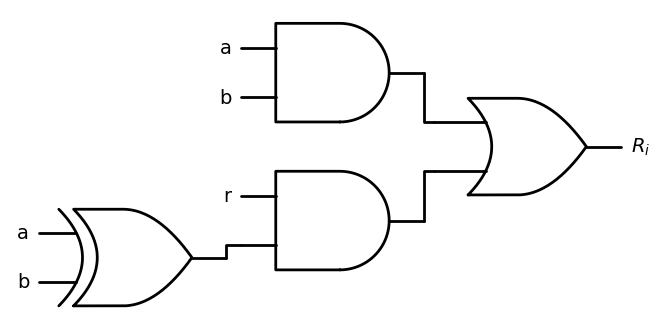

In [4]:
draw_circuit("(a and b) or (r and (a xor b))", "R_i")

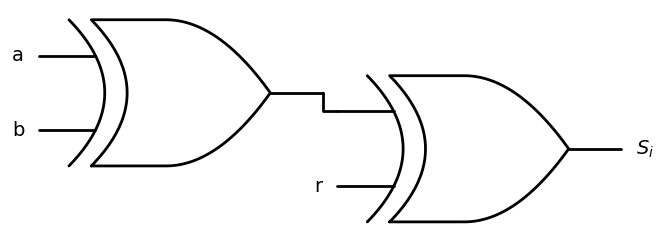

In [5]:
draw_circuit("(a xor b) xor r", "S_i")

## 3 · *n*-bit ripple-carry adder

Chain $n$ full adders: the carry out of stage $i$ becomes the carry in of stage $i+1$ (it *ripples*). The first
carry-in is $r_0 = 0$. The last carry $r_n$ is the **Carry Flag (CF)** stored in the status register.

A 4-bit adder has $4 + 4 + 1 = 9$ inputs, so its truth table would have $2^9 = 512$ rows: impossible to write by hand,
which is exactly why we **compose** from the 1-bit block. In code, however, we can still *prove* the design on all 512 cases.

In [6]:
def ripple_adder(A: str, B: str, carry_in: int = 0):
    """Add two n-bit words (MSB first). Returns (CF, sum bits, per-stage trace)."""
    assert len(A) == len(B)
    n, carry, out, rows = len(A), carry_in, [], []
    for stage in range(1, n + 1):                      # stage 1 = least significant bit
        a, b = int(A[n - stage]), int(B[n - stage])
        s, new_carry = full_adder(a, b, carry)
        rows.append((stage, a, b, carry, s, new_carry))
        out.append(str(s))
        carry = new_carry
    trace = table(rows, ["stage i", "a_i", "b_i", "r_(i-1)", "s_i", "r_i"])
    return carry, "".join(reversed(out)), trace


cf, s, trace = ripple_adder("1011", "0110")            # 11 + 6 = 17 -> needs 5 bits
print(f"1011 + 0110 = CF:{cf} S:{s}   ->   {cf}{s} (2) = {int(str(cf) + s, 2)}")
trace

1011 + 0110 = CF:1 S:0001   ->   10001 (2) = 17


,stage i,a_i,b_i,r_(i-1),s_i,r_i
0,1,1,0,0,1,0
1,2,1,1,0,0,1
2,3,0,1,1,0,1
3,4,1,0,1,0,1


In [7]:
# Exhaustive verification: 16 x 16 x 2 = 512 input combinations
failures = 0
for A, B, cin in itertools.product(range(16), range(16), (0, 1)):
    cf, s, _ = ripple_adder(format(A, "04b"), format(B, "04b"), cin)
    if cf * 16 + int(s, 2) != A + B + cin:
        failures += 1
print(f"512 / 512 combinations checked against integer addition, failures = {failures}")
assert failures == 0

512 / 512 combinations checked against integer addition, failures = 0


## 4 · Decoder *n* → 2ⁿ

A decoder has $N$ input bits and $2^N$ outputs. For every input code **exactly one** output is 1 (output $S_i$ is active
when the input equals $i$). It is used to **select** a memory cell, a register or an ALU operation from an address.

Each output is a single minterm: $S_0=\bar A\bar B,\; S_1=\bar A B,\; S_2=A\bar B,\; S_3=AB$ for the 2→4 decoder.

In [8]:
def decoder(bits, enable: int = 1) -> list[int]:
    """n-bit input -> list of 2**n one-hot outputs. With enable = 0 every output is 0."""
    index = int("".join(map(str, bits)), 2)
    return [int(enable and i == index) for i in range(2 ** len(bits))]


rows = [("X", "X", 0, *decoder((0, 0), enable=0))]                   # inhibited row of the course table
rows += [(a, b, 1, *decoder((a, b))) for a, b in itertools.product((0, 1), repeat=2)]
display(table(rows, ["A", "B", "En", "S0", "S1", "S2", "S3"]))

assert all(sum(decoder(bits)) == 1 for n in (2, 3, 4) for bits in itertools.product((0, 1), repeat=n))
print("Decoders 2->4, 3->8 and 4->16: exactly one active output for every input code.")

,A,B,En,S0,S1,S2,S3
0,X,X,0,0,0,0,0
1,0,0,1,1,0,0,0
2,0,1,1,0,1,0,0
3,1,0,1,0,0,1,0
4,1,1,1,0,0,0,1


Decoders 2->4, 3->8 and 4->16: exactly one active output for every input code.


address (1, 0) -> {'S0': 0, 'S1': 0, 'S2': 1, 'S3': 0}


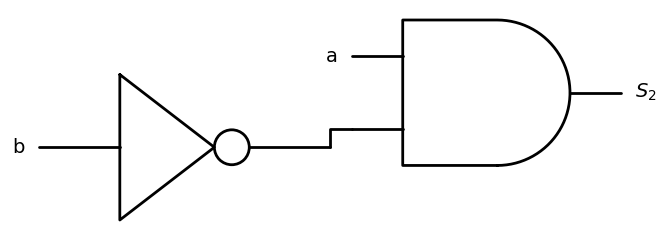

In [9]:
# Memory addressing: address 10 (binary) activates cell S2 only
address = (1, 0)
lines = decoder(address)
print("address", address, "->", {f"S{i}": v for i, v in enumerate(lines)})
draw_circuit("a and (not b)", "S_2")

### TD2 – Exercise 2, part 4: the recruitment function Z with a 4 → 16 decoder

Z is the OR of the decoder outputs whose index is a minterm of Z (found in notebook 03).

In [10]:
Z_minterms = [3, 4, 5, 6, 7, 11, 12, 13, 14, 15]          # published correction: Z = S3+S4+S5+S6+S7+S11+...+S15

def Z_with_decoder(a, b, c, d) -> int:
    s = decoder((a, b, c, d))
    return OR(*[s[i] for i in Z_minterms])

Z_minimal = lambda a, b, c, d: OR(b, AND(c, d))            # simplified form from the Karnaugh map: b + c.d
assert all(Z_with_decoder(*v) == Z_minimal(*v) for v in itertools.product((0, 1), repeat=4))
print("Decoder + 1 OR gate (10 inputs)  ==  b + c.d (1 AND + 1 OR)   on all 16 inputs.")

onehot = table([(*bits, *decoder(bits)) for bits in itertools.product((0, 1), repeat=4)],
               list("ABCD") + [f"S{i}" for i in range(16)])
onehot

Decoder + 1 OR gate (10 inputs)  ==  b + c.d (1 AND + 1 OR)   on all 16 inputs.


,A,B,C,D,S0,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13,S14,S15
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
6,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
9,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


### TD2 – Exercise 4: prove that F is always 1

Circuit: $A\oplus B$ and $C\oplus D$ drive the two inputs of a 2→4 decoder; the four decoder outputs feed one 4-input XOR gate.

**Argument.** A decoder always has *exactly one* active output, so the XOR receives exactly **one** 1.
An XOR outputs 1 when the number of 1-inputs is **odd**; 1 is odd, hence $F=1$ whatever $A,B,C,D$ are.

In [11]:
def circuit_ex4(A, B, C, D) -> int:
    outputs = decoder((XOR(A, B), XOR(C, D)))     # 2->4 decoder driven by two XOR gates
    return XOR(*outputs)                          # 4-input XOR = odd parity


results = {bits: circuit_ex4(*bits) for bits in itertools.product((0, 1), repeat=4)}
assert all(v == 1 for v in results.values())
print("F = 1 for all", len(results), "input combinations: proved by exhaustion and by the parity argument.")

F = 1 for all 16 input combinations: proved by exhaustion and by the parity argument.


## 5 · Comparator (TD2 – Exercise 3)

A 1-bit comparator of $X$ and $Y$ has three outputs; **exactly one** is 1:

| Output | Meaning | Equation |
|---|---|---|
| $G$ | $X > Y$ | $X\cdot\bar Y$ |
| $E$ | $X = Y$ | $\overline{X\oplus Y}$ (XNOR) |
| $L$ | $X < Y$ | $\bar X\cdot Y$ |

In [12]:
def comparator_1bit(x: int, y: int) -> tuple[int, int, int]:
    return AND(x, NOT(y)), XNOR(x, y), AND(NOT(x), y)      # (G, E, L)


display(table([(x, y, *comparator_1bit(x, y)) for x, y in itertools.product((0, 1), repeat=2)],
              ["X", "Y", "G (X>Y)", "E (X=Y)", "L (X<Y)"]))
assert all(sum(comparator_1bit(x, y)) == 1 for x, y in itertools.product((0, 1), repeat=2))

,X,Y,G (X>Y),E (X=Y),L (X<Y)
0,0,0,0,1,0
1,0,1,0,0,1
2,1,0,1,0,0
3,1,1,0,1,0


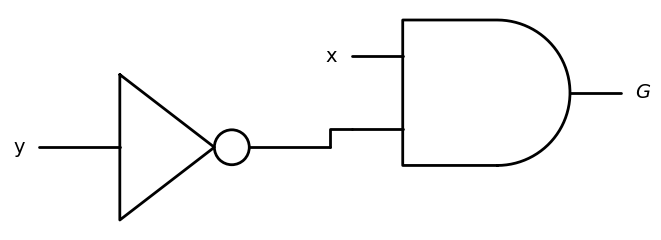

In [13]:
draw_circuit("x and (not y)", "G")

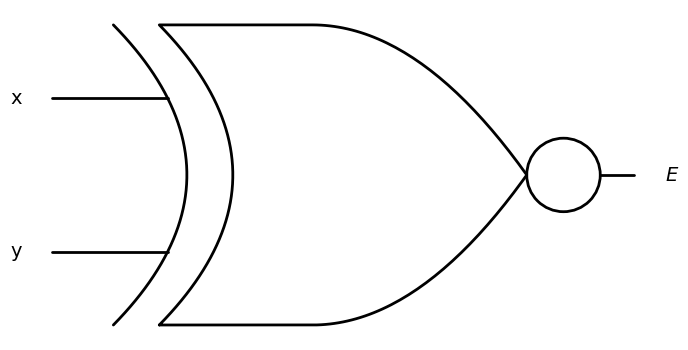

In [14]:
draw_circuit("not (x xor y)", "E")

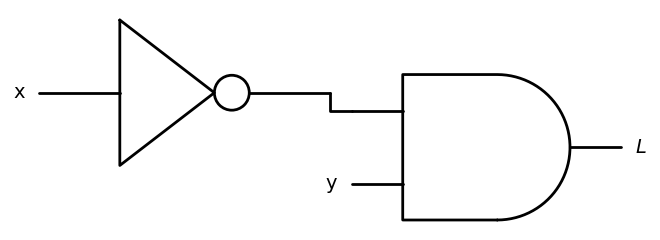

In [15]:
draw_circuit("(not x) and y", "L")

**Extension – *n*-bit comparator.** Scan from the most significant bit: *greater* is decided at the first bit pair that differs;
the words are *equal* only if every pair is equal. Built from the 1-bit blocks and verified on all 256 pairs of 4-bit words:

In [16]:
def comparator(X: str, Y: str) -> str:
    gt, eq = 0, 1
    for x, y in zip(X, Y):                              # MSB first
        g, e, _ = comparator_1bit(int(x), int(y))
        gt = OR(gt, AND(eq, g))                         # already greater, or equal so far and greater here
        eq = AND(eq, e)                                 # still equal
    return ">" if gt else ("=" if eq else "<")


for a, b in itertools.product(range(16), repeat=2):
    exp = ">" if a > b else ("=" if a == b else "<")
    assert comparator(format(a, "04b"), format(b, "04b")) == exp
print("4-bit comparator verified on 256 / 256 pairs.")

4-bit comparator verified on 256 / 256 pairs.


## 6 · Clock and timing

A sequential circuit is **synchronous** when its state changes only at the *edges* of a clock signal. The clock alternates
between 1 and 0; each transition is a *tick*. The **period** $T$ is the time of one full cycle and the **frequency** is
$f = 1/T$ (in hertz).

In [17]:
def si_time(seconds: float) -> str:
    for unit, scale in (("s", 1), ("ms", 1e-3), ("µs", 1e-6), ("ns", 1e-9), ("ps", 1e-12)):
        if seconds >= scale * 0.999:
            return f"{seconds / scale:g} {unit}"
    return f"{seconds:g} s"


freqs = {"1 Hz": 1, "1 kHz": 1e3, "1 MHz": 1e6, "1 GHz": 1e9, "2 GHz": 2e9, "3.2 GHz": 3.2e9}
display(table([(k, si_time(1 / f)) for k, f in freqs.items()], ["frequency", "period T = 1/f"]))
assert si_time(1 / 1e6) == "1 µs" and si_time(1 / 1e9) == "1 ns"           # values quoted in the course

,frequency,period T = 1/f
0,1 Hz,1 s
1,1 kHz,1 ms
2,1 MHz,1 µs
3,1 GHz,1 ns
4,2 GHz,500 ps
5,3.2 GHz,312.5 ps


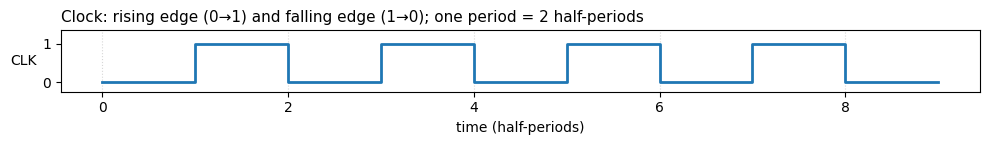

In [18]:
def plot_timing(signals: dict[str, list[int]], title: str = "", rising_edges: list[int] | None = None) -> None:
    fig, axes = plt.subplots(len(signals), 1, sharex=True, figsize=(10, 0.85 * len(signals) + 0.7))
    for ax, (name, vals) in zip(np.atleast_1d(axes), signals.items()):
        ax.step(range(len(vals) + 1), vals + [vals[-1]], where="post", lw=2)
        ax.set_ylim(-0.25, 1.35); ax.set_yticks([0, 1])
        ax.set_ylabel(name, rotation=0, ha="right", va="center")
        ax.grid(axis="x", ls=":", alpha=0.5)
        for t in rising_edges or []:
            ax.axvline(t, color="grey", lw=0.6, alpha=0.5)
    np.atleast_1d(axes)[0].set_title(title, loc="left", fontsize=11)
    np.atleast_1d(axes)[-1].set_xlabel("time (half-periods)")
    plt.tight_layout(); plt.show()


n_cycles = 4
clk = [0] + [1, 0] * n_cycles                       # low, then (high, low) x n  -> rising edges at t = 1, 3, 5, ...
plot_timing({"CLK": clk}, "Clock: rising edge (0→1) and falling edge (1→0); one period = 2 half-periods")

## 7 · SR latch from two NOR gates

Two NOR gates with **cross-coupled feedback** make the simplest memory element:

$$Q = \overline{R + \bar Q}\qquad \bar Q = \overline{S + Q}$$

| R | S | effect |
|:-:|:-:|---|
| 0 | 0 | **hold** – memory |
| 0 | 1 | **set**: Q = 1 |
| 1 | 0 | **reset**: Q = 0 |
| 1 | 1 | **forbidden**: Q = $\bar Q$ = 0 (outputs are no longer complementary) |

The simulation updates both gates simultaneously until the outputs stop changing (a *stable* state).

In [19]:
def sr_latch(R: int, S: int, Q: int, Qb: int, max_iter: int = 8):
    """Iterate the cross-coupled NOR gates. Returns (Q, Qbar, 'stable' | 'oscillates')."""
    for _ in range(max_iter):
        new_Q, new_Qb = NOR(R, Qb), NOR(S, Q)         # both gates evaluate at the same time
        if (new_Q, new_Qb) == (Q, Qb):
            return Q, Qb, "stable"
        Q, Qb = new_Q, new_Qb
    return Q, Qb, "oscillates"


rows = []
for R, S, Q in itertools.product((0, 1), repeat=3):
    q, qb, status = sr_latch(R, S, Q, NOT(Q))
    rows.append((R, S, Q, q, qb, status))
display(table(rows, ["R", "S", "Q before", "Q after", "Q̄ after", "status"]))

,R,S,Q before,Q after,Q̄ after,status
0,0,0,0,0,1,stable
1,0,0,1,1,0,stable
2,0,1,0,1,0,stable
3,0,1,1,1,0,stable
4,1,0,0,0,1,stable
5,1,0,1,0,1,stable
6,1,1,0,0,0,stable
7,1,1,1,0,0,stable


In [20]:
# The course's case analysis
assert sr_latch(0, 1, 0, 1)[:2] == (1, 0)          # Case 1: R=0, S=1 -> Q=1, Q̄=0
assert sr_latch(1, 0, 1, 0)[:2] == (0, 1)          # Case 2: R=1, S=0 -> Q=0, Q̄=1
assert sr_latch(1, 1, 0, 1)[:2] == (0, 0)          # Case 3: R=1, S=1 -> Q=0, Q̄=0   (forbidden state)

# MEMORY: a short Set pulse is remembered after the input goes back to 0
Q, Qb = 0, 1
history = []
for R, S in [(0, 0), (0, 1), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0)]:
    Q, Qb, _ = sr_latch(R, S, Q, Qb)
    history.append((R, S, Q))
display(table(history, ["R", "S", "Q"]).T)
print("After S=1 the latch keeps Q=1 with R=S=0; after R=1 it keeps Q=0: it REMEMBERS.")

# Why (1,1) is forbidden: releasing both inputs at once leaves an undefined result
print("Release from R=S=1 to R=S=0 ->", sr_latch(0, 0, 0, 0))

,0,1,2,3,4,5,6
R,0,0,0,0,1,0,0
S,0,1,0,0,0,0,0
Q,0,1,1,1,0,0,0


After S=1 the latch keeps Q=1 with R=S=0; after R=1 it keeps Q=0: it REMEMBERS.
Release from R=S=1 to R=S=0 -> (0, 0, 'oscillates')


## 8 · D, T and JK flip-flops

A **flip-flop** (*bascule*) is a clocked latch: it samples its inputs only on the active clock edge. Each type is
defined by its **characteristic equation** $Q^+ = F(\text{inputs}, Q)$ (next state from present state).

| Type | Equation | Behaviour |
|---|---|---|
| **D** | $Q^+ = D$ | copies D (a 1-bit storage cell) |
| **T** | $Q^+ = T \oplus Q$ | T = 1 toggles, T = 0 holds (divide-by-2) |
| **JK** | $Q^+ = J\bar Q + \bar K Q$ | 00 hold, 01 reset, 10 set, 11 toggle (no forbidden state) |

In [21]:
FLIP_FLOPS = {
    "D":  lambda q, d: d,
    "T":  lambda q, t: XOR(q, t),
    "JK": lambda q, j, k: OR(AND(j, NOT(q)), AND(NOT(k), q)),
}

display(table([(q, d, FLIP_FLOPS["D"](q, d)) for q, d in itertools.product((0, 1), repeat=2)], ["Q", "D", "Q+"]))
display(table([(q, t, FLIP_FLOPS["T"](q, t)) for q, t in itertools.product((0, 1), repeat=2)], ["Q", "T", "Q+"]))
jk = table([(q, j, k, FLIP_FLOPS["JK"](q, j, k)) for q, j, k in itertools.product((0, 1), repeat=3)], ["Q", "J", "K", "Q+"])
display(jk)

# JK behaviour table
for q in (0, 1):
    assert FLIP_FLOPS["JK"](q, 0, 0) == q            # hold
    assert FLIP_FLOPS["JK"](q, 0, 1) == 0            # reset
    assert FLIP_FLOPS["JK"](q, 1, 0) == 1            # set
    assert FLIP_FLOPS["JK"](q, 1, 1) == NOT(q)       # toggle
# A T flip-flop is a JK with J = K = T
assert all(FLIP_FLOPS["T"](q, t) == FLIP_FLOPS["JK"](q, t, t) for q, t in itertools.product((0, 1), repeat=2))

,Q,D,Q+
0,0,0,0
1,0,1,1
2,1,0,0
3,1,1,1


,Q,T,Q+
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


,Q,J,K,Q+
0,0,0,0,0
1,0,0,1,0
2,0,1,0,1
3,0,1,1,1
4,1,0,0,1
5,1,0,1,0
6,1,1,0,1
7,1,1,1,0


## 9 · Application: a 3-bit synchronous counter

Three T flip-flops count 0 → 7 and wrap around. A stage must **toggle** when all lower bits are 1:

$$T_0 = 1,\qquad T_1 = Q_0,\qquad T_2 = Q_0 \cdot Q_1$$

This is a *sequential* circuit in the sense of the course: a combinational part computes the T inputs from the
present state, and the flip-flops (the memory) store the next state at each clock edge.

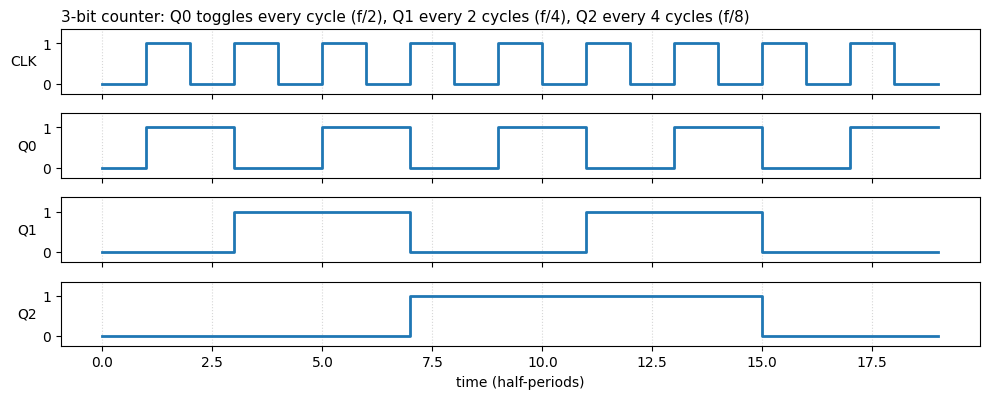

count sequence: [0, 1, 2, 3, 4, 5, 6, 7, 0, 1]


In [22]:
def simulate_counter(n_cycles: int):
    q0 = q1 = q2 = 0
    clk, Q0, Q1, Q2, values = [0], [0], [0], [0], [0]
    for _ in range(n_cycles):
        t0, t1, t2 = 1, q0, AND(q0, q1)                         # combinational part (from the PRESENT state)
        q0, q1, q2 = (FLIP_FLOPS["T"](q0, t0),                  # memory part: new state at the rising edge
                      FLIP_FLOPS["T"](q1, t1),
                      FLIP_FLOPS["T"](q2, t2))
        for level in (1, 0):                                    # one clock period = high half + low half
            clk.append(level); Q0.append(q0); Q1.append(q1); Q2.append(q2)
        values.append(q2 * 4 + q1 * 2 + q0)
    return clk, Q0, Q1, Q2, values


clk, Q0, Q1, Q2, values = simulate_counter(9)
assert values == [0, 1, 2, 3, 4, 5, 6, 7, 0, 1], values        # binary count with wrap-around
plot_timing({"CLK": clk, "Q0": Q0, "Q1": Q1, "Q2": Q2},
            "3-bit counter: Q0 toggles every cycle (f/2), Q1 every 2 cycles (f/4), Q2 every 4 cycles (f/8)")
print("count sequence:", values)

## Summary

| Circuit | Inputs → outputs | Key equation | Proof in this notebook |
|---|---|---|---|
| Half adder | 2 → 2 | $S=A\oplus B,\ R=AB$ | arithmetic check |
| Full adder | 3 → 2 | $S=a\oplus b\oplus r,\ R=ab+r(a\oplus b)$ | 8 rows |
| 4-bit adder | 9 → 5 | chain of 4 full adders | **512 / 512** cases |
| Decoder *n*→2ⁿ | *n* → 2ⁿ | one minterm per output | one-hot for all codes |
| Comparator | 2 → 3 | $X\bar Y,\ \overline{X\oplus Y},\ \bar X Y$ | 4 rows (+ 256 pairs, 4-bit) |
| SR latch | 2 → 2 | $Q=\overline{R+\bar Q}$ | memory demo |
| D / T / JK | – | $Q^+=D;\ T\oplus Q;\ J\bar Q+\bar K Q$ | behaviour tables |
| Counter | clock → 3 bits | $T_1=Q_0,\ T_2=Q_0Q_1$ | timing diagram |

**Next:** `05_memory_and_microprocessor.ipynb` – address spaces, buses and a fetch–decode–execute CPU simulator.